# Proyecto #2 - Data Mining (PBL)
## Semana 1: Comprension del Problema y Analisis Exploratorio de Datos
**Curso:** Mineria de Datos | **Universidad del Valle de Guatemala** | **Semestre I, 2026**

---

**Conjunto de datos:** Wisconsin Breast Cancer Dataset  
**Problema:** Clasificacion binaria — predecir si una masa mamaria es benigna o maligna  
**Variable objetivo:** `Class` (2 = Benigno, 4 = Maligno)

## 1. Importar las librerias

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Polars: {pl.__version__}')
print('Librerias cargadas correctamente.')

Polars: 1.39.3
Librerias cargadas correctamente.


## 2. Importar el conjunto de datos

In [2]:
datos = pl.read_csv('Datos.csv')
datos.head()

Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1000025,5,1,1,1,2,1,3,1,1,2
1002945,5,4,4,5,7,10,3,2,1,2
1015425,3,1,1,1,2,2,3,1,1,2
1016277,6,8,8,1,3,4,3,7,1,2
1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# Dimensiones del dataset
print(f'Forma: {datos.shape[0]} filas x {datos.shape[1]} columnas')

Forma: 683 filas x 11 columnas


In [4]:
# Esquema: nombres de columnas y tipos de datos
print('Esquema (columnas y tipos):')
print(datos.schema)

Esquema (columnas y tipos):
Schema({'Sample code number': Int64, 'Clump Thickness': Int64, 'Uniformity of Cell Size': Int64, 'Uniformity of Cell Shape': Int64, 'Marginal Adhesion': Int64, 'Single Epithelial Cell Size': Int64, 'Bare Nuclei': Int64, 'Bland Chromatin': Int64, 'Normal Nucleoli': Int64, 'Mitoses': Int64, 'Class': Int64})


In [5]:
# Estadisticas descriptivas de todas las columnas
datos.describe()

statistic,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",683.0,683.0,683.0,683.0,683.0,683.0,683.0,683.0,683.0,683.0,683.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.0767e6,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
"""std""",620644.047655,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
"""min""",63375.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
"""25%""",877943.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0
"""50%""",1.171795e6,4.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,2.0
"""75%""",1.238777e6,6.0,5.0,5.0,4.0,4.0,6.0,5.0,4.0,1.0,4.0
"""max""",1.3454352e7,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,4.0


## 3. Datos faltantes

In [6]:
# Conteo de valores nulos por columna
print('Valores nulos por columna:')
print(datos.null_count())

Valores nulos por columna:
shape: (1, 11)
┌─────────────┬───────────┬───────────────┬────────────────────┬───┬───────────┬─────────────────┬─────────┬───────┐
│ Sample code ┆ Clump     ┆ Uniformity of ┆ Uniformity of Cell ┆ … ┆ Bland     ┆ Normal Nucleoli ┆ Mitoses ┆ Class │
│ number      ┆ Thickness ┆ Cell Size     ┆ Shape              ┆   ┆ Chromatin ┆ ---             ┆ ---     ┆ ---   │
│ ---         ┆ ---       ┆ ---           ┆ ---                ┆   ┆ ---       ┆ u32             ┆ u32     ┆ u32   │
│ u32         ┆ u32       ┆ u32           ┆ u32                ┆   ┆ u32       ┆                 ┆         ┆       │
╞═════════════╪═══════════╪═══════════════╪════════════════════╪═══╪═══════════╪═════════════════╪═════════╪═══════╡
│ 0           ┆ 0         ┆ 0             ┆ 0                  ┆ … ┆ 0         ┆ 0               ┆ 0       ┆ 0     │
└─────────────┴───────────┴───────────────┴────────────────────┴───┴───────────┴─────────────────┴─────────┴───────┘


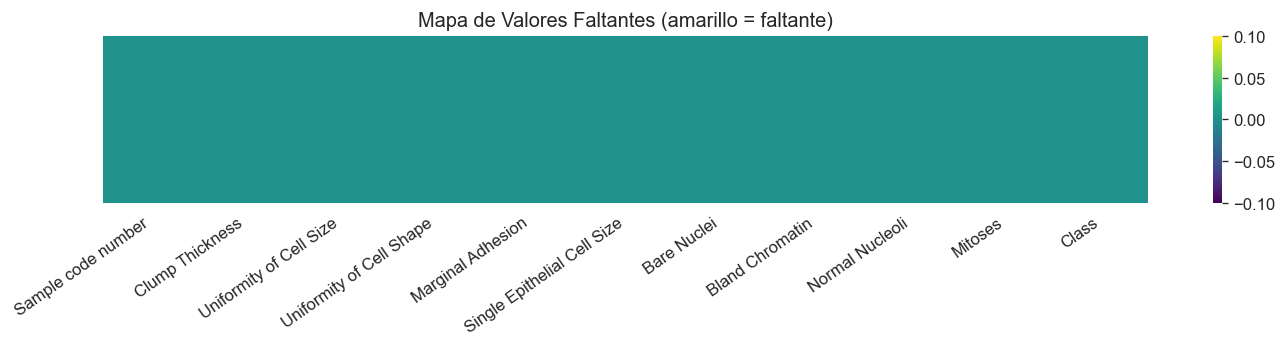

No hay valores faltantes. El dataset esta completo.


In [7]:
# Visualizacion de valores faltantes con mapa de calor
# (se convierte a numpy para compatibilidad con seaborn)
null_matrix = datos.select(pl.all().is_null().cast(pl.Int8)).to_numpy()

plt.figure(figsize=(12, 3))
sns.heatmap(null_matrix, yticklabels=False, cbar=True,
            cmap='viridis', xticklabels=datos.columns)
plt.title('Mapa de Valores Faltantes (amarillo = faltante)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('No hay valores faltantes. El dataset esta completo.')

## 4. Preparacion inicial

Se separa el identificador (`Sample code number`) que no es una variable predictora.  
Se agrega una columna `Diagnosis` con etiquetas legibles para la variable objetivo.

| Valor Class | Diagnostico |
|-------------|-------------|
| 2           | Benigno     |
| 4           | Maligno     |

In [8]:
FEATURES = [
    'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
    'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei',
    'Bland Chromatin', 'Normal Nucleoli', 'Mitoses'
]

# Agregar etiqueta de diagnostico usando expresiones Polars
datos = datos.with_columns(
    pl.when(pl.col('Class') == 2)
      .then(pl.lit('Benigno'))
      .otherwise(pl.lit('Maligno'))
      .alias('Diagnosis')
)

print('Primeras filas con columna Diagnosis:')
datos.select(['Sample code number', 'Clump Thickness', 'Class', 'Diagnosis']).head()

Primeras filas con columna Diagnosis:


Sample code number,Clump Thickness,Class,Diagnosis
i64,i64,i64,str
1000025,5,2,"""Benigno"""
1002945,5,2,"""Benigno"""
1015425,3,2,"""Benigno"""
1016277,6,2,"""Benigno"""
1017023,4,2,"""Benigno"""


In [9]:
# Distribucion de la variable objetivo
n_total = datos.shape[0]
dist = datos.group_by('Diagnosis').len().sort('Diagnosis')
print('Distribucion de clases:')
for row in dist.iter_rows(named=True):
    print(f"  {row['Diagnosis']:10s}: {row['len']:4d} registros  ({row['len']/n_total*100:.1f}%)")

Distribucion de clases:
  Benigno   :  444 registros  (65.0%)
  Maligno   :  239 registros  (35.0%)


## 5. Analisis Exploratorio de Datos (Visualizaciones)

### Figura 1: Distribucion de clases

Primera revision critica: un desbalance significativo puede sesgar los modelos hacia la clase mayoritaria.

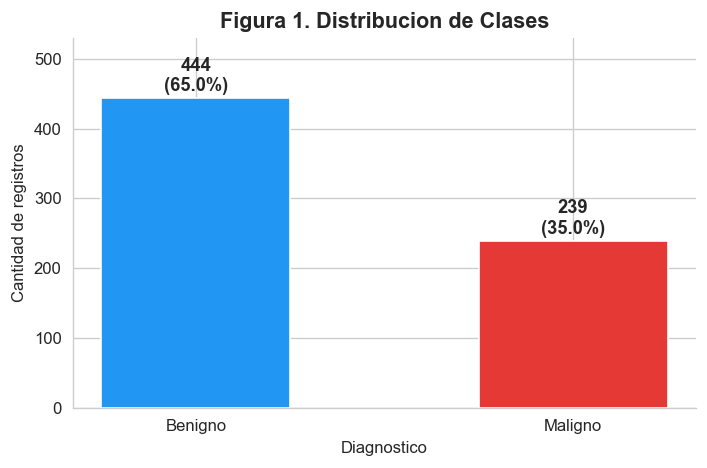

Interpretacion: Desbalance moderado (65% benigno / 35% maligno).
Se priorizara F1-score y AUC-ROC sobre exactitud simple.


In [10]:
colors = {'Benigno': '#2196F3', 'Maligno': '#E53935'}
dist_pd = dist.to_pandas()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(dist_pd['Diagnosis'], dist_pd['len'],
              color=[colors[k] for k in dist_pd['Diagnosis']],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, dist_pd['len']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'{val}\n({val/n_total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Figura 1. Distribucion de Clases', fontsize=13, fontweight='bold')
ax.set_ylabel('Cantidad de registros')
ax.set_xlabel('Diagnostico')
ax.set_ylim(0, 530)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Interpretacion: Desbalance moderado (65% benigno / 35% maligno).')
print('Se priorizara F1-score y AUC-ROC sobre exactitud simple.')

### Figura 2: Boxplots por variable y clase

Permite comparar la distribucion de cada variable entre ambas clases. Una separacion marcada indica alto poder discriminante.

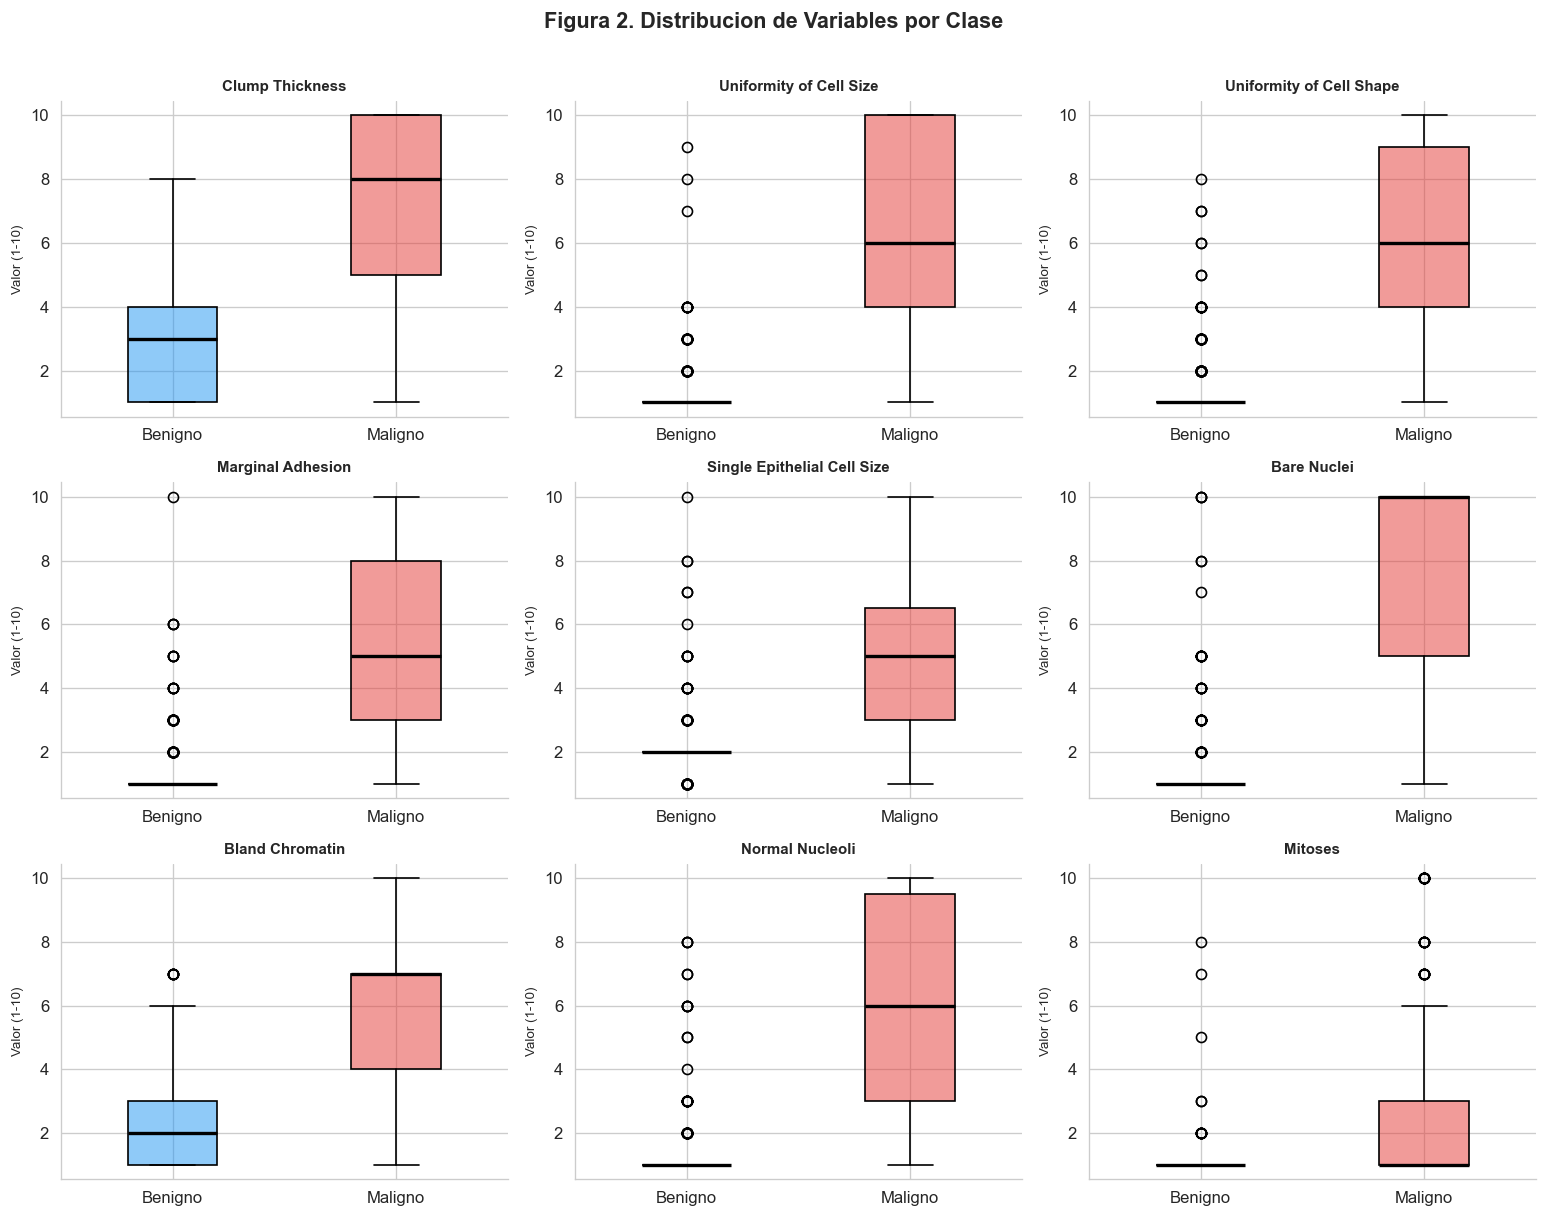

Interpretacion: Todas las variables muestran separacion entre clases.
Mayor separacion en: Uniformity of Cell Size, Uniformity of Cell Shape, Bare Nuclei.


In [11]:
# Extraer grupos como arrays numpy (requerido por matplotlib)
df_b = datos.filter(pl.col('Diagnosis') == 'Benigno')
df_m = datos.filter(pl.col('Diagnosis') == 'Maligno')

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data_b = df_b[feat].to_numpy()
    data_m = df_m[feat].to_numpy()
    # NOTA: En matplotlib >= 3.9 el parametro 'labels' fue renombrado a 'tick_labels'
    bp = ax.boxplot([data_b, data_m],
                    tick_labels=['Benigno', 'Maligno'],
                    patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2196F380')
    bp['boxes'][1].set_facecolor('#E5393580')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Valor (1-10)', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Figura 2. Distribucion de Variables por Clase',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Interpretacion: Todas las variables muestran separacion entre clases.')
print('Mayor separacion en: Uniformity of Cell Size, Uniformity of Cell Shape, Bare Nuclei.')

### Figura 3: Matriz de correlacion

Revela relaciones lineales entre predictores. Correlaciones altas entre variables indican multicolinealidad, que puede afectar modelos lineales como regresion logistica.

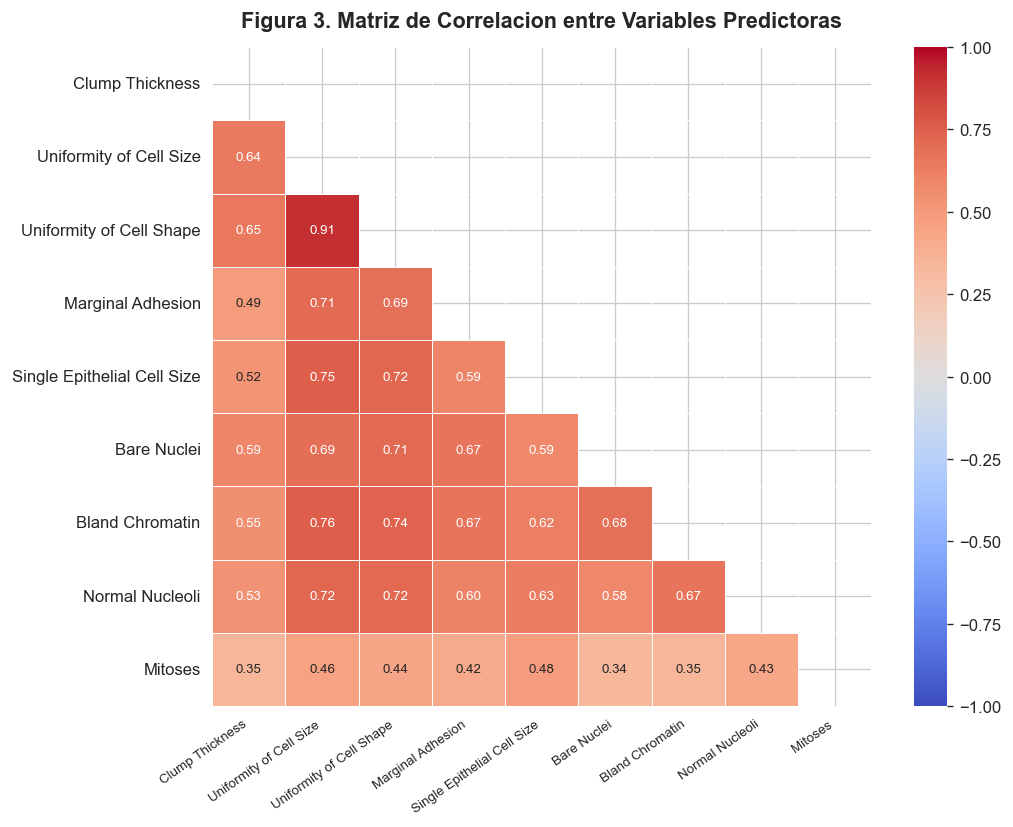

Par con mayor correlacion: Uniformity of Cell Size <-> Uniformity of Cell Shape: r = 0.9072
Alta multicolinealidad entre variables de uniformidad celular.


In [12]:
# Calcular matriz de correlacion (Polars -> numpy)
n_feat = len(FEATURES)
arrays = {f: datos[f].to_numpy().astype(float) for f in FEATURES}
corr_matrix = np.zeros((n_feat, n_feat))
for i, fi in enumerate(FEATURES):
    for j, fj in enumerate(FEATURES):
        corr_matrix[i, j] = np.corrcoef(arrays[fi], arrays[fj])[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones((n_feat, n_feat), dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=FEATURES, yticklabels=FEATURES,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Figura 3. Matriz de Correlacion entre Variables Predictoras',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# Par mas correlacionado
max_r, par = 0, ('', '')
for i in range(n_feat):
    for j in range(i+1, n_feat):
        if corr_matrix[i, j] > max_r:
            max_r = corr_matrix[i, j]
            par = (FEATURES[i], FEATURES[j])
print(f'Par con mayor correlacion: {par[0]} <-> {par[1]}: r = {max_r:.4f}')
print('Alta multicolinealidad entre variables de uniformidad celular.')

### Figura 4: Valor promedio de variables por clase

Comparacion rapida de que variables distinguen mejor los grupos. Se calculan las medias con `group_by` de Polars.

Medias por clase:
shape: (2, 10)
┌───────────┬───────────┬─────────────────┬─────────────────┬───┬─────────────┬───────────┬─────────────────┬──────────┐
│ Diagnosis ┆ Clump     ┆ Uniformity of   ┆ Uniformity of   ┆ … ┆ Bare Nuclei ┆ Bland     ┆ Normal Nucleoli ┆ Mitoses  │
│ ---       ┆ Thickness ┆ Cell Size       ┆ Cell Shape      ┆   ┆ ---         ┆ Chromatin ┆ ---             ┆ ---      │
│ str       ┆ ---       ┆ ---             ┆ ---             ┆   ┆ f64         ┆ ---       ┆ f64             ┆ f64      │
│           ┆ f64       ┆ f64             ┆ f64             ┆   ┆             ┆ f64       ┆                 ┆          │
╞═══════════╪═══════════╪═════════════════╪═════════════════╪═══╪═════════════╪═══════════╪═════════════════╪══════════╡
│ Benigno   ┆ 2.963964  ┆ 1.306306        ┆ 1.414414        ┆ … ┆ 1.346847    ┆ 2.083333  ┆ 1.261261        ┆ 1.065315 │
│ Maligno   ┆ 7.188285  ┆ 6.577406        ┆ 6.560669        ┆ … ┆ 7.627615    ┆ 5.974895  ┆ 5.857741        ┆ 2.60251  │

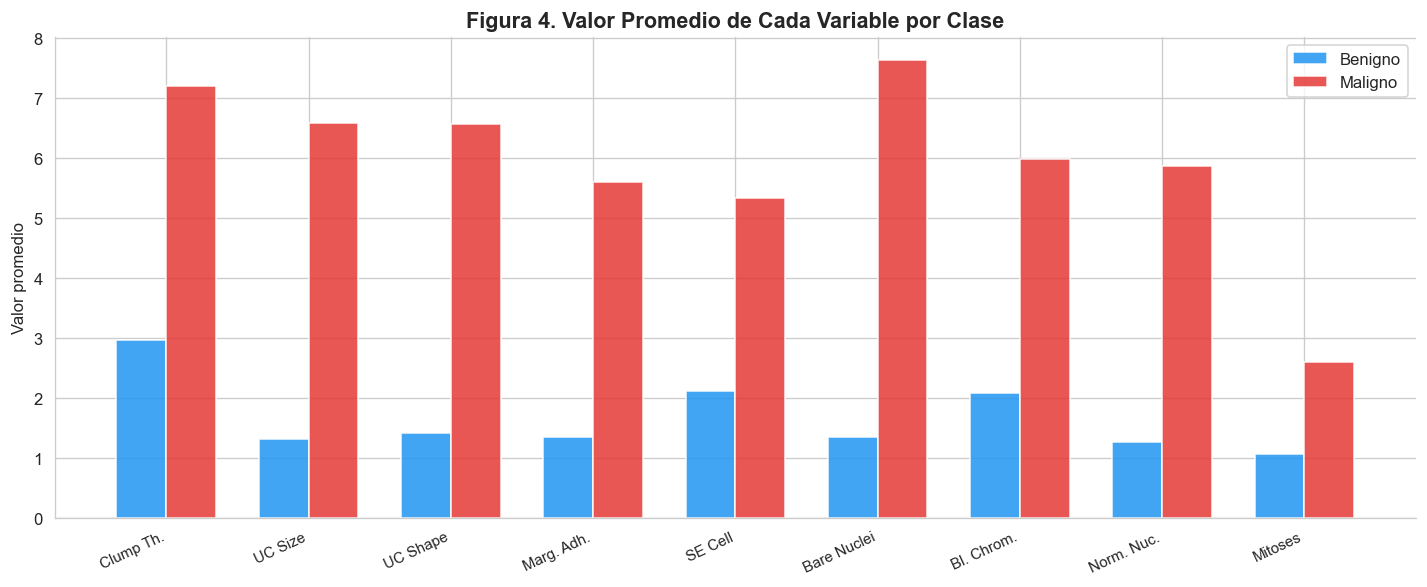

Diferencia de medias (Maligno - Benigno):
  Clump Thickness                    : +4.22
  Uniformity of Cell Size            : +5.27
  Uniformity of Cell Shape           : +5.15
  Marginal Adhesion                  : +4.24
  Single Epithelial Cell Size        : +3.22
  Bare Nuclei                        : +6.28
  Bland Chromatin                    : +3.89
  Normal Nucleoli                    : +4.60
  Mitoses                            : +1.54


In [13]:
# Medias por clase con Polars
means = datos.group_by('Diagnosis').agg(
    [pl.col(f).mean().alias(f) for f in FEATURES]
).sort('Diagnosis')
print('Medias por clase:')
print(means)

means_b = means.filter(pl.col('Diagnosis') == 'Benigno').select(FEATURES).row(0)
means_m = means.filter(pl.col('Diagnosis') == 'Maligno').select(FEATURES).row(0)

x = np.arange(len(FEATURES))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, means_b, width, label='Benigno', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, means_m, width, label='Maligno', color='#E53935', alpha=0.85)
etiquetas = [
    f.replace('Uniformity of Cell ','UC ').replace('Single Epithelial Cell Size','SE Cell')
     .replace('Marginal Adhesion','Marg. Adh.').replace('Bland Chromatin','Bl. Chrom.')
     .replace('Normal Nucleoli','Norm. Nuc.').replace('Clump Thickness','Clump Th.')
    for f in FEATURES
]
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Valor promedio')
ax.set_title('Figura 4. Valor Promedio de Cada Variable por Clase',
             fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Diferencia de medias (Maligno - Benigno):')
for f, b, m in zip(FEATURES, means_b, means_m):
    print(f'  {f:<35s}: {m-b:+.2f}')

### Figura 5: Datos atipicos por variable (criterio IQR)

Un valor es atipico si cae fuera del rango [Q1 - 1.5*IQR, Q3 + 1.5*IQR].  
Se usa `filter` de Polars para el conteo.

C:\Users\paula\AppData\Local\Temp\ipykernel_7808\190627544.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etiq, rotation=25, ha='right', fontsize=9)


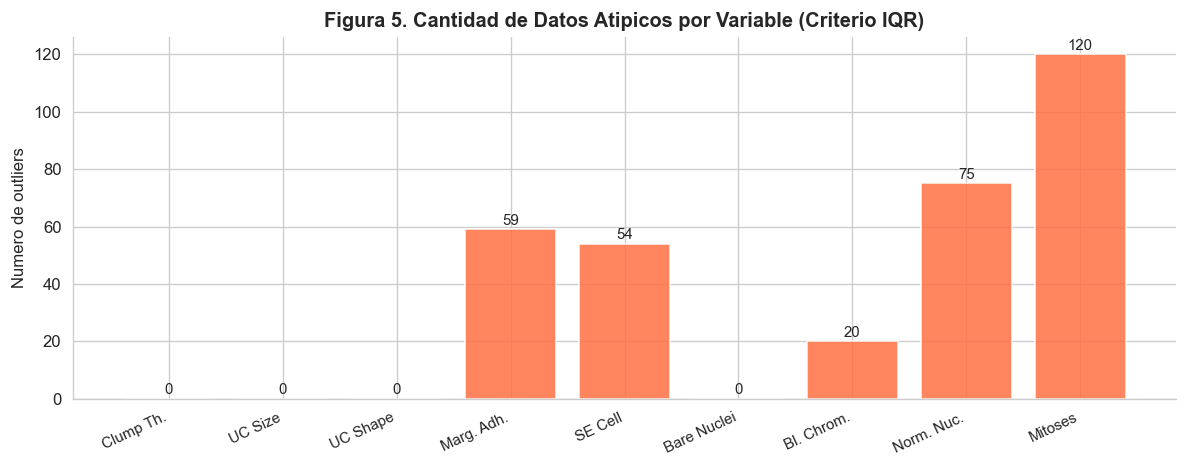

Outliers por variable (mayor a menor):
  Mitoses                            : 120
  Normal Nucleoli                    : 75
  Marginal Adhesion                  : 59
  Single Epithelial Cell Size        : 54
  Bland Chromatin                    : 20
  Clump Thickness                    : 0
  Uniformity of Cell Size            : 0
  Uniformity of Cell Shape           : 0
  Bare Nuclei                        : 0

Nota: Son biologicamente plausibles, no se eliminaran.


In [14]:
outlier_counts = {}
for feat in FEATURES:
    q1 = float(datos.select(pl.col(feat).quantile(0.25)).item())
    q3 = float(datos.select(pl.col(feat).quantile(0.75)).item())
    iqr = q3 - q1
    n_out = datos.filter(
        (pl.col(feat) < q1 - 1.5 * iqr) | (pl.col(feat) > q3 + 1.5 * iqr)
    ).shape[0]
    outlier_counts[feat] = n_out

etiq = [
    f.replace('Uniformity of Cell ','UC ').replace('Single Epithelial Cell Size','SE Cell')
     .replace('Marginal Adhesion','Marg. Adh.').replace('Bland Chromatin','Bl. Chrom.')
     .replace('Normal Nucleoli','Norm. Nuc.').replace('Clump Thickness','Clump Th.')
    for f in FEATURES
]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(etiq, list(outlier_counts.values()), color='#FF7043', alpha=0.85)
for bar, val in zip(bars, outlier_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_title('Figura 5. Cantidad de Datos Atipicos por Variable (Criterio IQR)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Numero de outliers')
ax.set_xticklabels(etiq, rotation=25, ha='right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Outliers por variable (mayor a menor):')
for k, v in sorted(outlier_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<35s}: {v}')
print('\nNota: Son biologicamente plausibles, no se eliminaran.')

### Figura 6: Histogramas de las variables con mayor poder discriminante

Distribucion superpuesta de las 3 variables con mayor correlacion con el diagnostico.

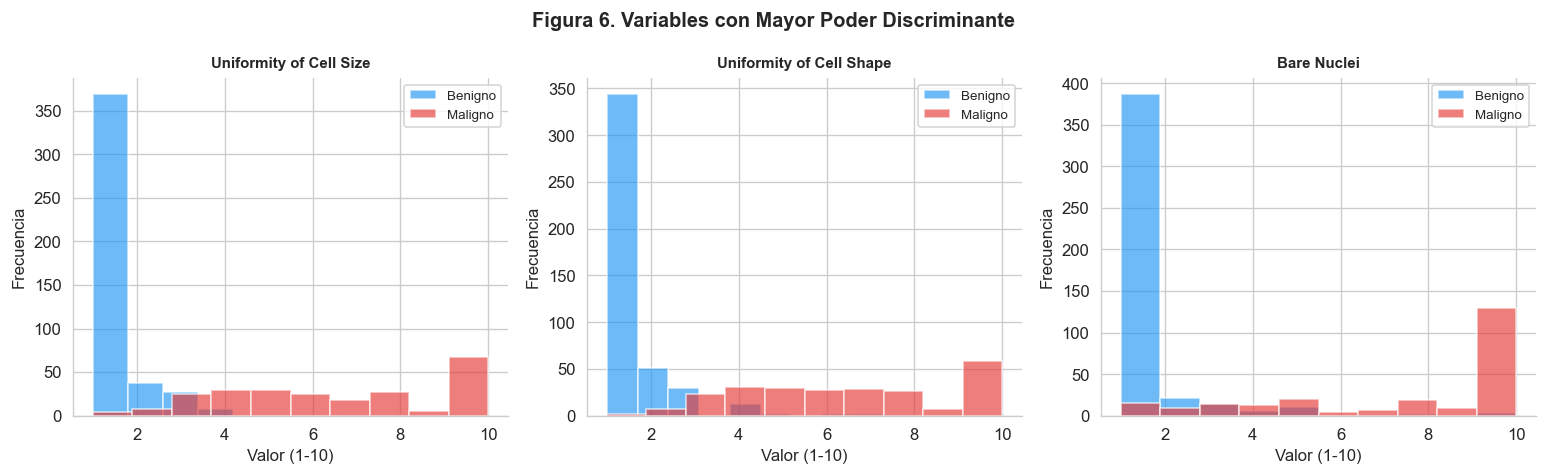

Benigno: concentrado en valores 1-2 (normalidad celular).
Maligno: distribucion dispersa con masa en valores altos (8-10).


In [15]:
top3 = ['Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Bare Nuclei']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, feat in zip(axes, top3):
    for diag, color in colors.items():
        vals = datos.filter(pl.col('Diagnosis') == diag)[feat].to_numpy()
        ax.hist(vals, bins=10, alpha=0.65, label=diag, color=color, edgecolor='white')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor (1-10)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Figura 6. Variables con Mayor Poder Discriminante',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Benigno: concentrado en valores 1-2 (normalidad celular).')
print('Maligno: distribucion dispersa con masa en valores altos (8-10).')

## 6. Correlacion de variables con la variable objetivo

Se rankean los predictores segun su correlacion de Pearson con `Class`.

In [16]:
target = datos['Class'].to_numpy().astype(float)
corr_target = {}
for feat in FEATURES:
    r = np.corrcoef(datos[feat].to_numpy().astype(float), target)[0, 1]
    corr_target[feat] = round(r, 4)

print('Correlacion con la variable objetivo (Class), de mayor a menor:')
for feat, r in sorted(corr_target.items(), key=lambda x: -x[1]):
    barra = '#' * int(r * 30)
    print(f'  {feat:<35s}: {r:.4f}  {barra}')

print()
print('Variables con alta correlacion (r > 0.70):')
print([f for f, r in corr_target.items() if r > 0.70])

Correlacion con la variable objetivo (Class), de mayor a menor:
  Bare Nuclei                        : 0.8227  ########################
  Uniformity of Cell Shape           : 0.8219  ########################
  Uniformity of Cell Size            : 0.8208  ########################
  Bland Chromatin                    : 0.7582  ######################
  Normal Nucleoli                    : 0.7187  #####################
  Clump Thickness                    : 0.7148  #####################
  Marginal Adhesion                  : 0.7063  #####################
  Single Epithelial Cell Size        : 0.6910  ####################
  Mitoses                            : 0.4234  ############

Variables con alta correlacion (r > 0.70):
['Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli']


## 7. Estadisticas descriptivas por grupo

Se calculan estadisticas clave por clase para entender las diferencias entre grupos.

In [17]:
for diag in ['Benigno', 'Maligno']:
    grupo = datos.filter(pl.col('Diagnosis') == diag).select(FEATURES)
    print(f'--- {diag} ({datos.filter(pl.col("Diagnosis")==diag).shape[0]} registros) ---')
    print(grupo.describe())
    print()

--- Benigno (444 registros) ---
shape: (9, 10)
┌────────────┬───────────┬────────────────────┬────────────────────┬───┬─────────────┬───────────┬──────────┬──────────┐
│ statistic  ┆ Clump     ┆ Uniformity of Cell ┆ Uniformity of Cell ┆ … ┆ Bare Nuclei ┆ Bland     ┆ Normal   ┆ Mitoses  │
│ ---        ┆ Thickness ┆ Size               ┆ Shape              ┆   ┆ ---         ┆ Chromatin ┆ Nucleoli ┆ ---      │
│ str        ┆ ---       ┆ ---                ┆ ---                ┆   ┆ f64         ┆ ---       ┆ ---      ┆ f64      │
│            ┆ f64       ┆ f64                ┆ f64                ┆   ┆             ┆ f64       ┆ f64      ┆          │
╞════════════╪═══════════╪════════════════════╪════════════════════╪═══╪═════════════╪═══════════╪══════════╪══════════╡
│ count      ┆ 444.0     ┆ 444.0              ┆ 444.0              ┆ … ┆ 444.0       ┆ 444.0     ┆ 444.0    ┆ 444.0    │
│ null_count ┆ 0.0       ┆ 0.0                ┆ 0.0                ┆ … ┆ 0.0         ┆ 0.0       ┆ 0.0    

## 8. Hipotesis iniciales

Con base en el EDA, se establecen las siguientes hipotesis para guiar el modelado:

1. **Variables mas discriminantes:** `Uniformity of Cell Size`, `Uniformity of Cell Shape` y `Bare Nuclei` seran los predictores de mayor importancia (r > 0.82 con la clase objetivo).

2. **Separabilidad lineal:** La clara separacion visual entre clases sugiere que modelos lineales como Regresion Logistica podrian obtener buen desempeno.

3. **Mitoses como predictor debil:** Presenta la correlacion mas baja (r ≈ 0.42) y es la variable menos discriminante, aunque aporta informacion independiente.

4. **Efecto del desbalance:** El desbalance 65/35 requiere estratificacion en el split y el uso de F1-score como metrica principal.

5. **Multicolinealidad:** La alta correlacion entre `Uniformity of Cell Size` y `Uniformity of Cell Shape` (r > 0.90) podria afectar modelos sensibles a ella.